In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
# plt.rcParams['font.size'] = 14
# sns.set(font_scale=2)

# Load DataSet

In [2]:
data = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\weatherAUS_rainfall_prediction_dataset_cleaned.csv")
data.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,NW,9.0,7.0,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,No
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,NNE,0.0,11.0,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,No
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,NE,9.0,20.0,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,Yes
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,NW,17.0,26.0,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,Yes
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,WNW,13.0,15.0,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,Yes


# Explore Data Analysis

## Data Types and Missing Values

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [6]:
data.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [7]:
data.shape

(145460, 23)

# Feature Engginering

We found anomaly data type at column 'Date' which is must be a date time type not as 'object' type.

In [8]:
#Konversi data type 'Date'
data['Date'] = pd.to_datetime(data['Date'])

In [9]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data.drop(columns=['Date'], inplace=True)

In [10]:
data.sample()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
142460,Woomera,18.2,31.7,0.2,12.2,7.2,WSW,46.0,E,E,15.0,7.0,50.0,25.0,1014.3,1011.9,5.0,7.0,22.7,29.9,No,No,2009,3,11


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 25 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       145460 non-null  object 
 1   MinTemp        145460 non-null  float64
 2   MaxTemp        145460 non-null  float64
 3   Rainfall       145460 non-null  float64
 4   Evaporation    145460 non-null  float64
 5   Sunshine       145460 non-null  float64
 6   WindGustDir    145460 non-null  object 
 7   WindGustSpeed  145460 non-null  float64
 8   WindDir9am     145460 non-null  object 
 9   WindDir3pm     145460 non-null  object 
 10  WindSpeed9am   145460 non-null  float64
 11  WindSpeed3pm   145460 non-null  float64
 12  Humidity9am    145460 non-null  float64
 13  Humidity3pm    145460 non-null  float64
 14  Pressure9am    145460 non-null  float64
 15  Pressure3pm    145460 non-null  float64
 16  Cloud9am       145460 non-null  float64
 17  Cloud3pm       145460 non-nul

In [12]:
# Add column 'season' 
def assign_season(month):
    if month in [12,1,2]:
        return "Summer"
    elif month in [3,4,5]:
        return "Autumn"
    elif month in [6,7,8]:
        return "Winter"
    else:
        return "Spring"

In [13]:
#add column season
data['Season'] = data['Month'].apply(assign_season)

In [14]:
data[['Month', 'Season']].sample(10)

,Month,Season
100526,7,Winter
4695,1,Summer
72795,5,Autumn
11837,3,Autumn
74317,9,Spring
127589,9,Spring
127780,2,Summer
131692,8,Winter
83626,9,Spring
112147,8,Winter


In [15]:
data.sample(3)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day,Season
50949,Katherine,16.3,33.4,0.0,8.00,7.61,ESE,31.00,N,SSE,0.0,17.0,66.0,36.0,1012.30,1008.40,2.00,3.00,23.8,32.2,No,No,2013,4,13,Autumn
74824,Newcastle,16.6,25.0,0.0,5.47,7.61,W,40.04,N,SE,0.0,4.0,70.0,58.0,1017.65,1015.26,8.00,6.00,21.4,23.2,No,No,2014,4,8,Autumn
89890,Penrith,4.2,22.3,0.0,5.47,7.61,WSW,43.00,NW,W,4.0,22.0,50.0,31.0,1017.65,1015.26,4.45,4.51,13.0,20.2,No,No,2009,8,31,Winter


In [16]:
# Pastikan RainTomorrow diubah menjadi 1 (Yes) dan 0 (No)
data['RainTomorrow_binary'] = data['RainTomorrow'].map({'Yes': 1, 'No': 0})

# 🔍 Data Analysis

## 🔍 1. Analisis Distribusi Target

<Figure size 600x400 with 0 Axes>

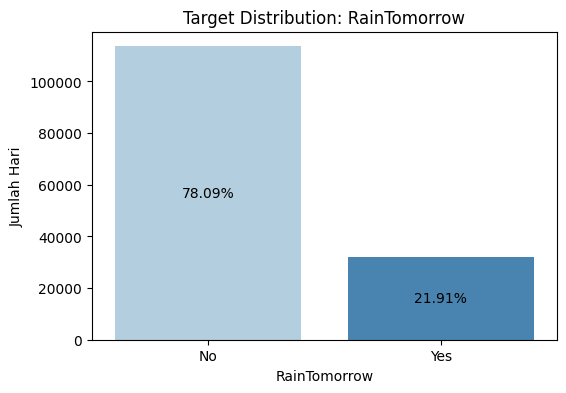

In [17]:
# --- 1. Distribusi Target: RainTomorrow ---
plt.figure(figsize=(6,4))
plt.figure(figsize=(6,4))
ax = sns.countplot(x='RainTomorrow', data=data, hue='RainTomorrow', palette='Blues', legend=False)

plt.title('Target Distribution: RainTomorrow', fontsize=12)
plt.xlabel('RainTomorrow')
plt.ylabel('Jumlah Hari')

# Tambahkan label persentase di tengah batang
total = len(data)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height/2,   # di tengah batang
            f"{height/total*100:.2f}%", 
            ha='center', va='center', color='black', fontsize=10)

plt.show()

## 🌧️ 2. Analisis Hujan Berdasarkan Lokasi  
Tujuan: melihat lokasi mana yang paling sering hujan esok hari.

### 1️⃣ Top 10 lokasi dengan hujan esok hari paling sering

In [18]:
rain_count = (
    data.groupby("Location")['RainTomorrow_binary']
    .sum()
    .sort_values(ascending=False)
)

In [19]:
top10_rain_locations = rain_count.head(10)
print("Top 10 lokasi dengan hujan esok hari paling sering:\n")
print(top10_rain_locations)

Top 10 lokasi dengan hujan esok hari paling sering:

Location
Portland         1095
Cairns            950
Walpole           949
Dartmoor          922
MountGambier      920
NorfolkIsland     919
Albany            902
Witchcliffe       879
CoffsHarbour      869
Sydney            865
Name: RainTomorrow_binary, dtype: int64


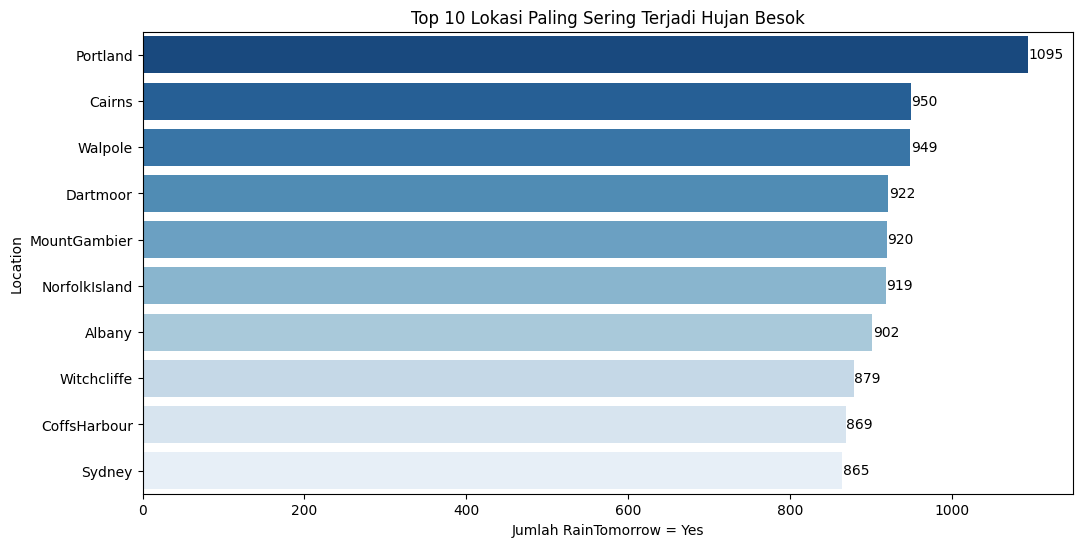

In [20]:
# Visualisasi
plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=top10_rain_locations.values,
    y=top10_rain_locations.index,
    hue=top10_rain_locations.index,
    palette="Blues_r",
    legend=False
)

# Tambahkan label di ujung batang
for i, v in enumerate(top10_rain_locations.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.title("Top 10 Lokasi Paling Sering Terjadi Hujan Besok")
plt.xlabel("Jumlah RainTomorrow = Yes")
plt.ylabel("Location")
plt.show()

### 2️⃣ Lokasi paling basah vs paling kering

In [21]:
most_rainy_location = rain_count.idxmax()
least_rainy_location = rain_count.idxmin()

In [22]:
print("\nLokasi paling basah (RainTomorrow paling sering):", most_rainy_location)
print("Lokasi paling kering (RainTomorrow paling jarang):", least_rainy_location)


Lokasi paling basah (RainTomorrow paling sering): Portland
Lokasi paling kering (RainTomorrow paling jarang): Uluru


### 3️⃣ Tren hujan per wilayah (persentase)

In [23]:
rain_percentage = (
    data.groupby("Location")['RainTomorrow_binary']
    .mean()
    .sort_values(ascending=False)
)


Persentase hujan esok hari per lokasi (top 10):

Location
Portland         36.39
Walpole          31.57
Cairns           31.25
Dartmoor         30.64
NorfolkIsland    30.54
MountGambier     30.26
Albany           29.67
Witchcliffe      29.21
CoffsHarbour     28.88
MountGinini      26.94
Name: RainTomorrow_binary, dtype: float64


C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\84617941.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rain_percentage.values, y=rain_percentage.index, palette="coolwarm")


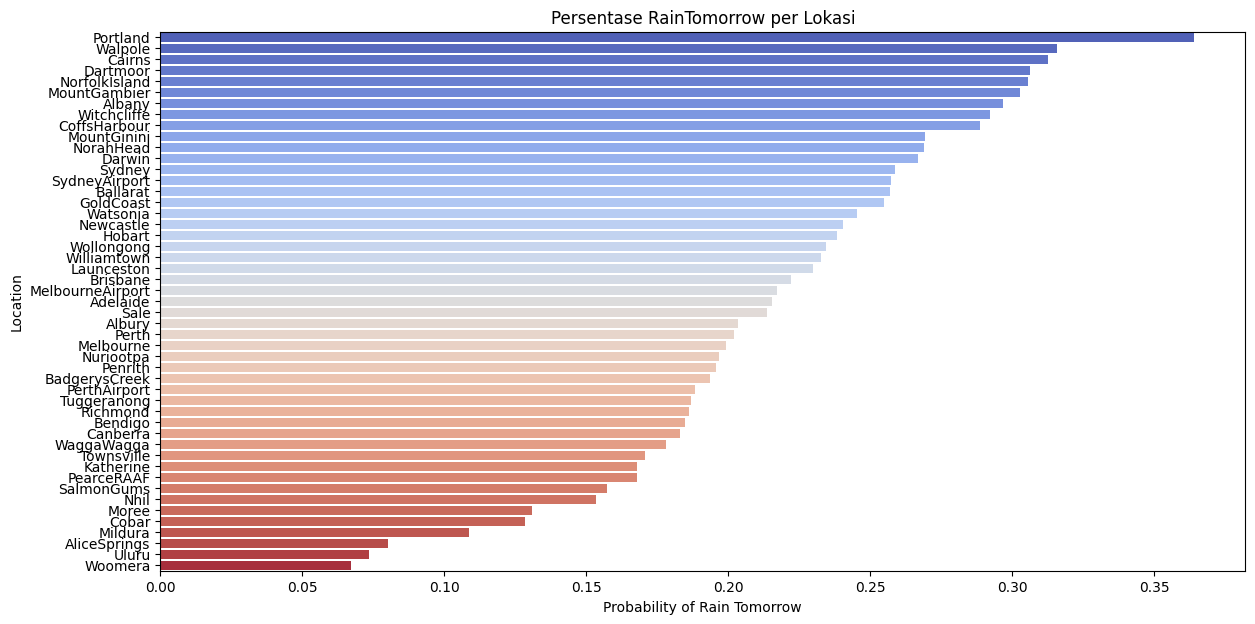

In [24]:
print("\nPersentase hujan esok hari per lokasi (top 10):\n")
print((rain_percentage.head(10) * 100).round(2))

# Visualisasi persentase hujan per lokasi
plt.figure(figsize=(14,7))
sns.barplot(x=rain_percentage.values, y=rain_percentage.index, palette="coolwarm")
plt.title("Persentase RainTomorrow per Lokasi")
plt.xlabel("Probability of Rain Tomorrow")
plt.ylabel("Location")
plt.show()

## 📅 3. Analisis RainTomorrow Berdasarkan Waktu

### 1️⃣ Analisis RainTomorrow berdasarkan Month

In [25]:
rain_by_month = (
    data.groupby("Month")["RainTomorrow_binary"]
    .mean()
    .sort_index()
)

print("Persentase RainTomorrow berdasarkan Month:\n")
print((rain_by_month * 100).round(2))

Persentase RainTomorrow berdasarkan Month:

Month
1     18.87
2     20.45
3     20.81
4     21.32
5     22.03
6     25.58
7     26.37
8     24.69
9     22.39
10    19.21
11    20.88
12    20.28
Name: RainTomorrow_binary, dtype: float64


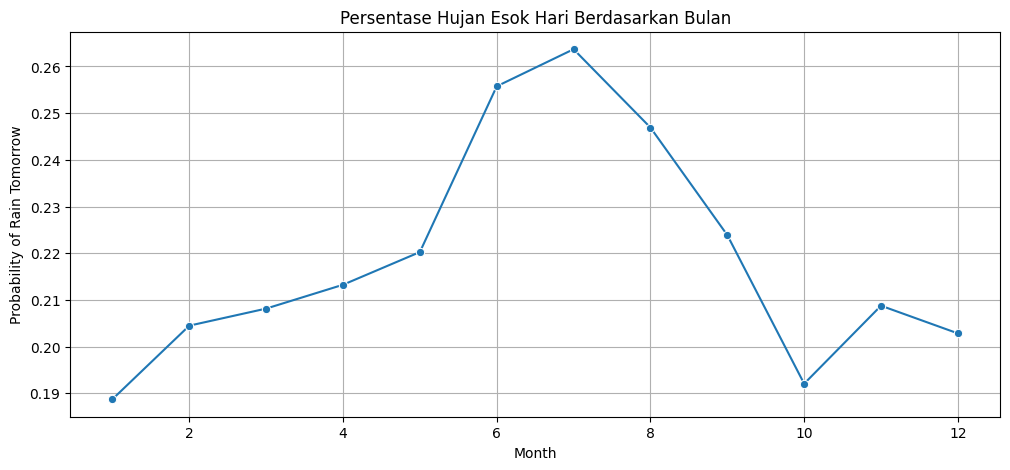

In [26]:
# Visualisasi
plt.figure(figsize=(12,5))
sns.lineplot(x=rain_by_month.index, y=rain_by_month.values, marker="o")
plt.title("Persentase Hujan Esok Hari Berdasarkan Bulan")
plt.xlabel("Month")
plt.ylabel("Probability of Rain Tomorrow")
plt.grid(True)
plt.show()

### 2️⃣ Analisis RainTomorrow berdasarkan Season

In [27]:
rain_by_season = (
    data.groupby("Season")["RainTomorrow_binary"]
    .mean()
    .sort_values(ascending=False)
)

print("\nPersentase RainTomorrow berdasarkan Season:\n")
print((rain_by_season * 100).round(2))


Persentase RainTomorrow berdasarkan Season:

Season
Winter    25.55
Autumn    21.39
Spring    20.81
Summer    19.80
Name: RainTomorrow_binary, dtype: float64


C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\3548737829.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rain_by_season.index, y=rain_by_season.values, palette="Blues_d")


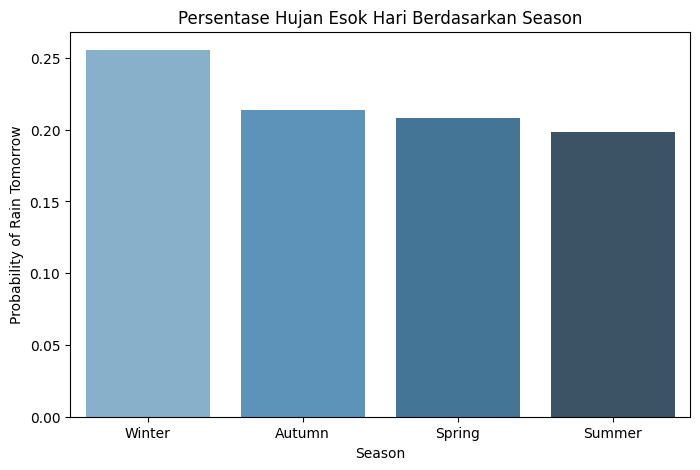

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(x=rain_by_season.index, y=rain_by_season.values, palette="Blues_d")
plt.title("Persentase Hujan Esok Hari Berdasarkan Season")
plt.ylabel("Probability of Rain Tomorrow")
plt.xlabel("Season")
plt.show()

### 3️⃣ Analisis RainTomorrow berdasarkan Year (trend tahunan)

In [30]:
rain_by_year = (
    data.groupby("Year")["RainTomorrow_binary"]
    .mean()
    .sort_index()
)

print("\nTren RainTomorrow berdasarkan Year:\n")
print((rain_by_year * 100).round(2))


Tren RainTomorrow berdasarkan Year:

Year
2007    31.15
2008    22.51
2009    21.48
2010    23.82
2011    24.26
2012    21.99
2013    21.11
2014    19.89
2015    20.40
2016    23.32
2017    20.45
Name: RainTomorrow_binary, dtype: float64


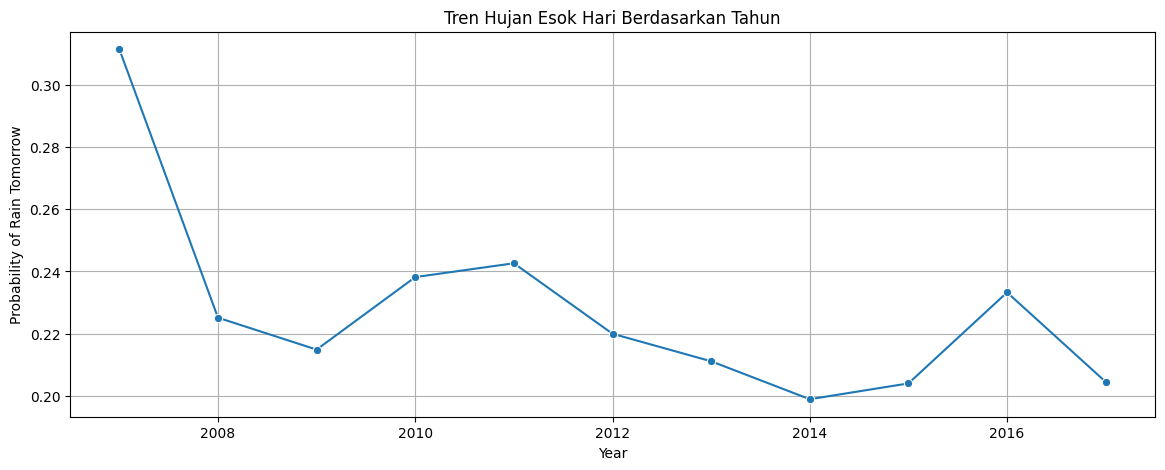

In [31]:
plt.figure(figsize=(14,5))
sns.lineplot(x=rain_by_year.index, y=rain_by_year.values, marker="o")
plt.title("Tren Hujan Esok Hari Berdasarkan Tahun")
plt.xlabel("Year")
plt.ylabel("Probability of Rain Tomorrow")
plt.grid(True)
plt.show()

### 4️⃣ RainTomorrow per Month untuk Setiap Tahun

In [33]:
# Membuat pivot table: index=Month, kolom=Year
monthly_yearly = (
    data.groupby(["Year", "Month"])["RainTomorrow_binary"]
    .mean()
    .reset_index()
)

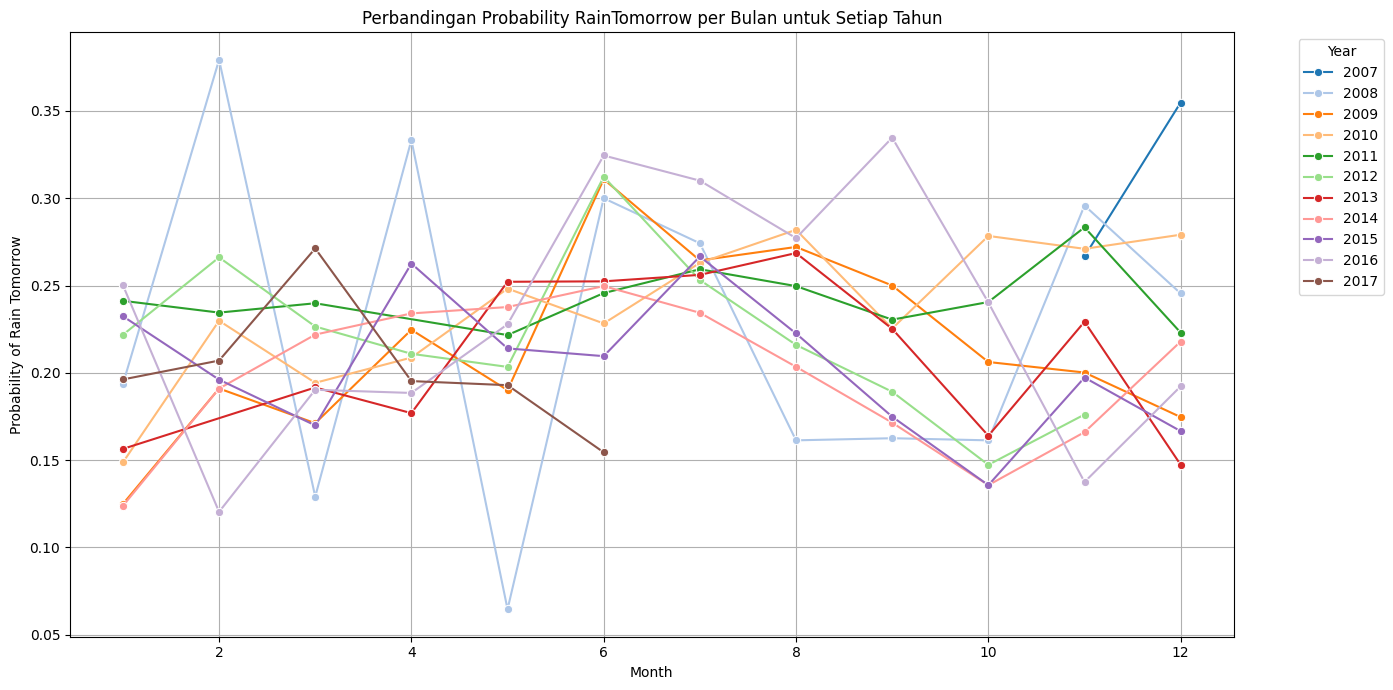

In [34]:
# Vizualisasion
plt.figure(figsize=(14,7))
sns.lineplot(
    data=monthly_yearly,
    x="Month",
    y="RainTomorrow_binary",
    hue="Year",
    palette="tab20",
    marker="o"
)

plt.title("Perbandingan Probability RainTomorrow per Bulan untuk Setiap Tahun")
plt.xlabel("Month")
plt.ylabel("Probability of Rain Tomorrow")
plt.grid(True)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 🌡️ 4. Hubungan Variabel Cuaca dengan RainTomorrow

In [38]:
data["RainToday_binary"] = data["RainToday"].map({"Yes": 1, "No": 0})

sns.set(style="whitegrid")

### 🌧️ A. RainToday vs RainTomorrow

In [39]:
# Probabilitas RainTomorrow berdasarkan RainToday
rt_relationship = (
    data.groupby("RainToday")["RainTomorrow_binary"]
    .mean()
    .rename("Probability")
)

print("Probabilitas RainTomorrow berdasarkan RainToday:")
print((rt_relationship * 100).round(2))

Probabilitas RainTomorrow berdasarkan RainToday:
RainToday
No     15.21
Yes    45.79
Name: Probability, dtype: float64


C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\2811471343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rt_relationship.index, y=rt_relationship.values, palette="Blues")


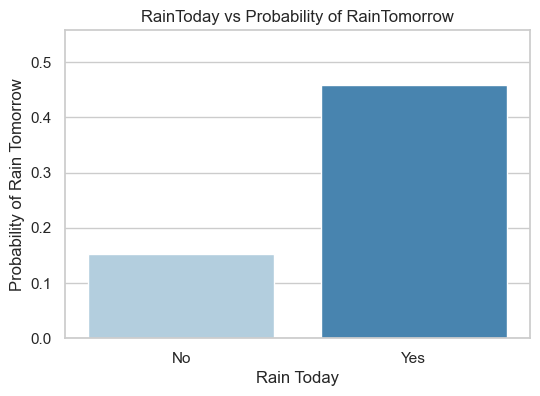

In [40]:
plt.figure(figsize=(6,4))
sns.barplot(x=rt_relationship.index, y=rt_relationship.values, palette="Blues")
plt.title("RainToday vs Probability of RainTomorrow")
plt.ylabel("Probability of Rain Tomorrow")
plt.xlabel("Rain Today")
plt.ylim(0, rt_relationship.max() + 0.1)
plt.show()

### 💧 B. Humidity3pm vs RainTomorrow

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\2554553489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="RainTomorrow", y="Humidity3pm", data=data, palette="Blues_r")


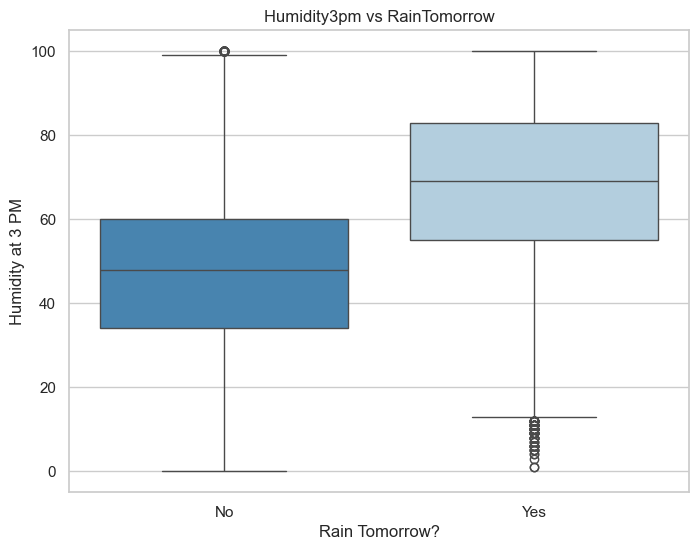

In [42]:
plt.figure(figsize=(8,6))
sns.boxplot(x="RainTomorrow", y="Humidity3pm", data=data, palette="Blues_r")
plt.title("Humidity3pm vs RainTomorrow")
plt.ylabel("Humidity at 3 PM")
plt.xlabel("Rain Tomorrow?")
plt.show()

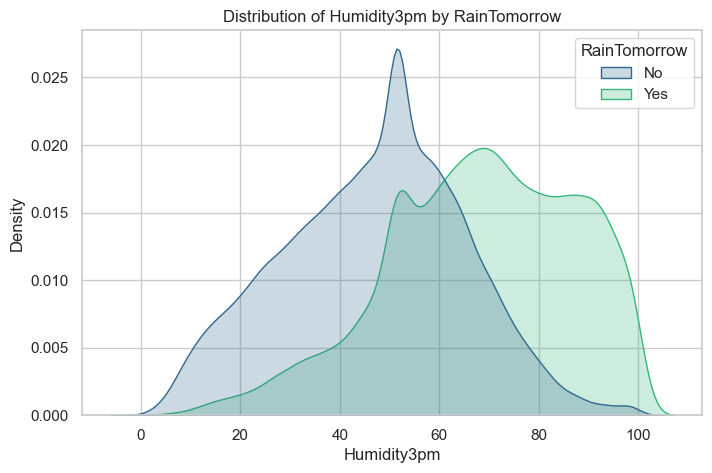

In [43]:
# Trend
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=data, 
    x="Humidity3pm", 
    hue="RainTomorrow",
    fill=True,
    common_norm=False,
    palette="viridis"
)
plt.title("Distribution of Humidity3pm by RainTomorrow")
plt.show()

### 🌬️ C. Pressure3pm vs RainTomorrow

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\3425700094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="RainTomorrow", y="Pressure3pm", data=data, palette="coolwarm")


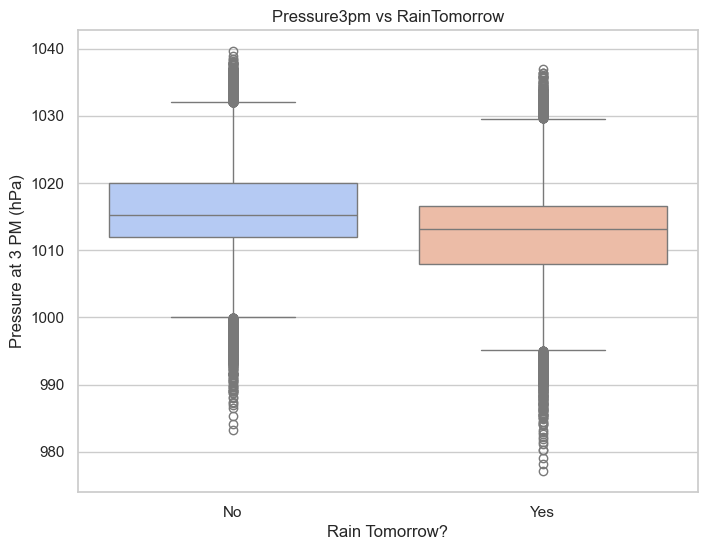

In [44]:
plt.figure(figsize=(8,6))
sns.boxplot(x="RainTomorrow", y="Pressure3pm", data=data, palette="coolwarm")
plt.title("Pressure3pm vs RainTomorrow")
plt.ylabel("Pressure at 3 PM (hPa)")
plt.xlabel("Rain Tomorrow?")
plt.show()


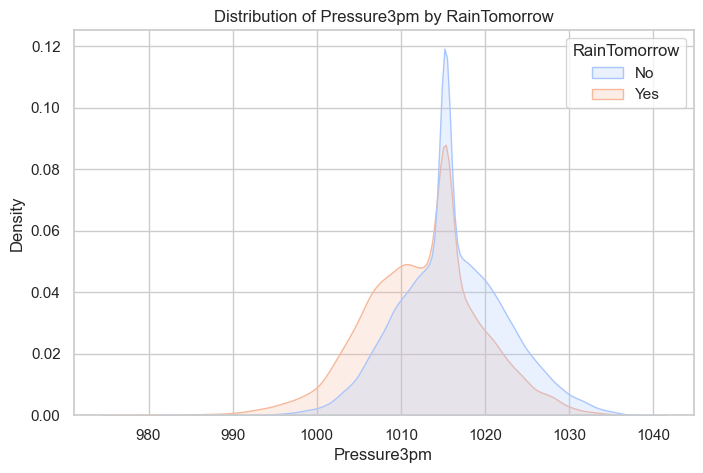

In [45]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=data,
    x="Pressure3pm",
    hue="RainTomorrow",
    fill=True,
    common_norm=False,
    palette="coolwarm"
)
plt.title("Distribution of Pressure3pm by RainTomorrow")
plt.show()

### Corelation Feature vs RainTomorrow

In [48]:
# Ambil semua kolom numerik (int / float)
numerical_cols = data.select_dtypes(include=['int32', 'int64', 'float64']).columns.tolist()

# Hapus kolom target dari list
numerical_cols = [col for col in numerical_cols if col != 'RainTomorrow_binary']

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


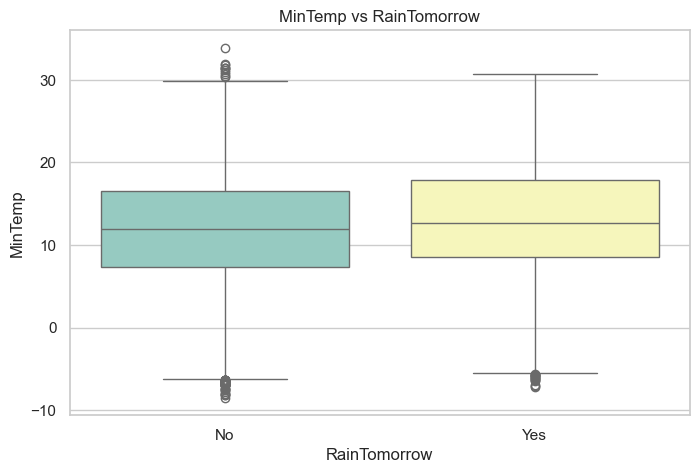

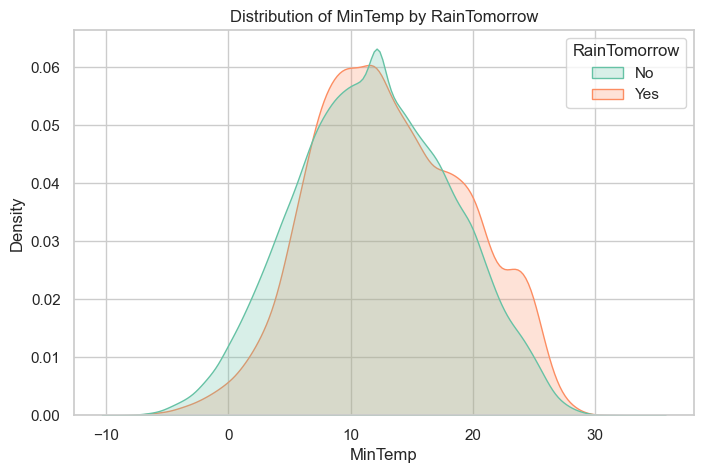

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


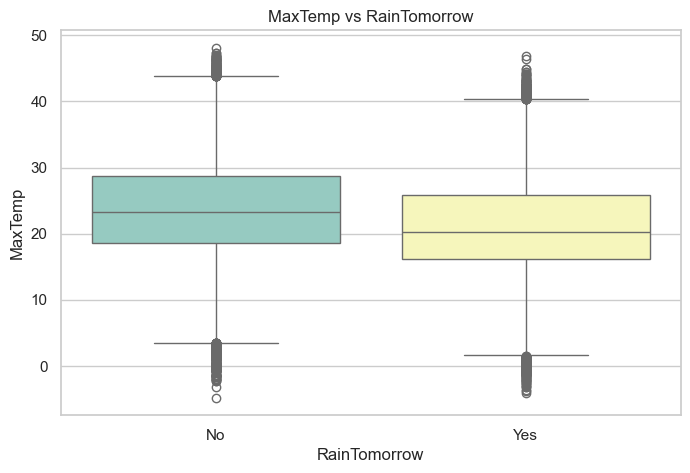

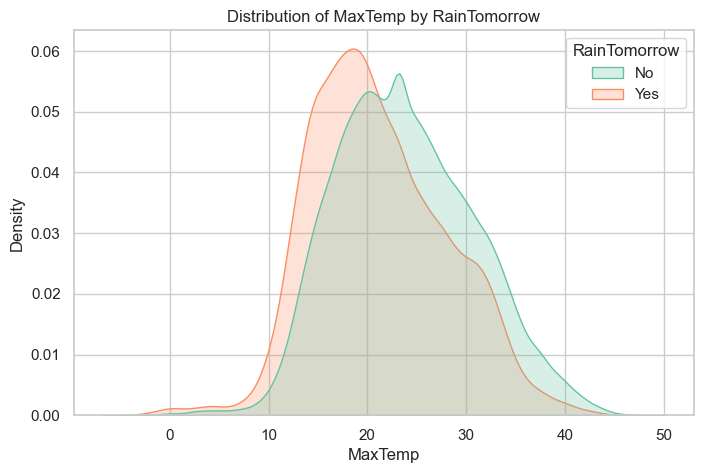

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


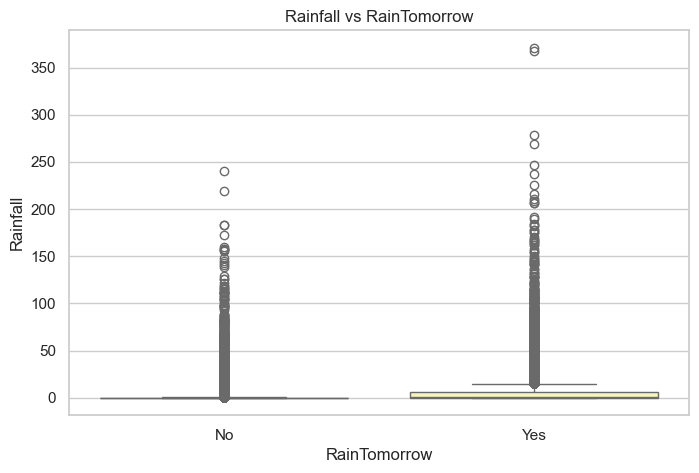

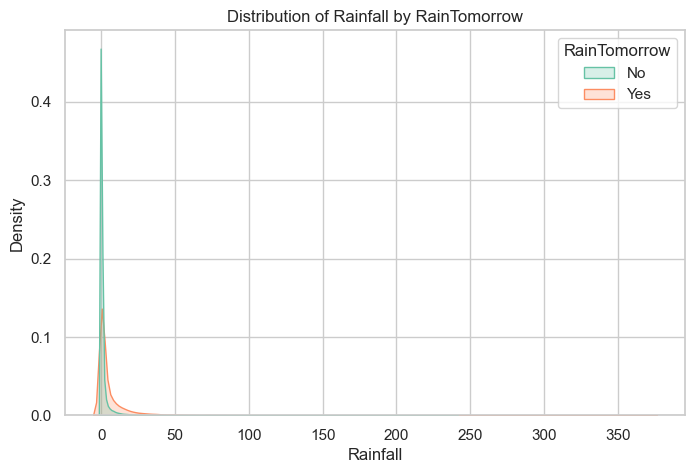

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


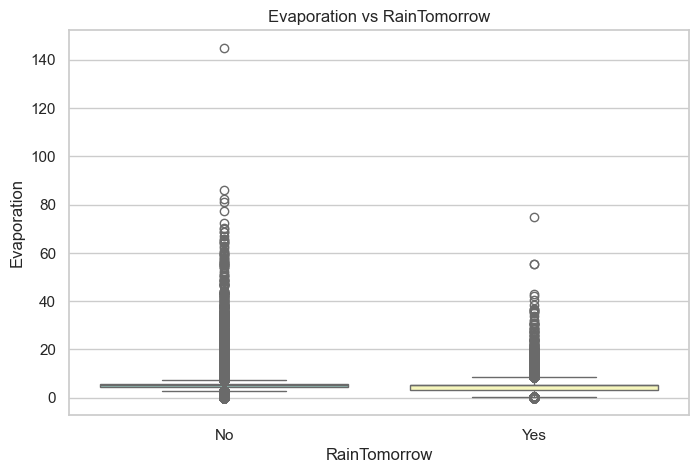

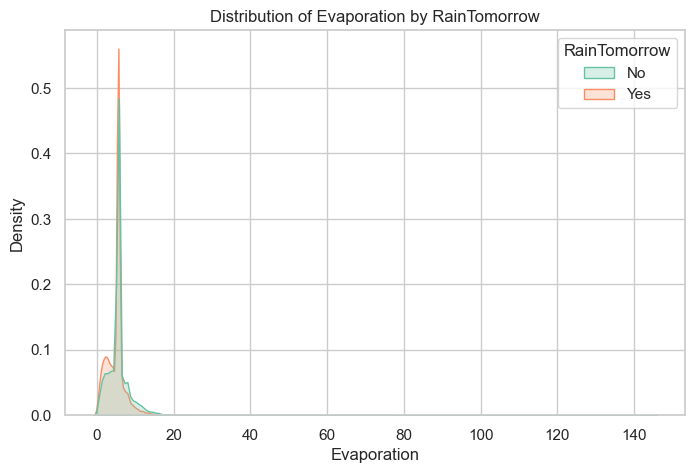

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


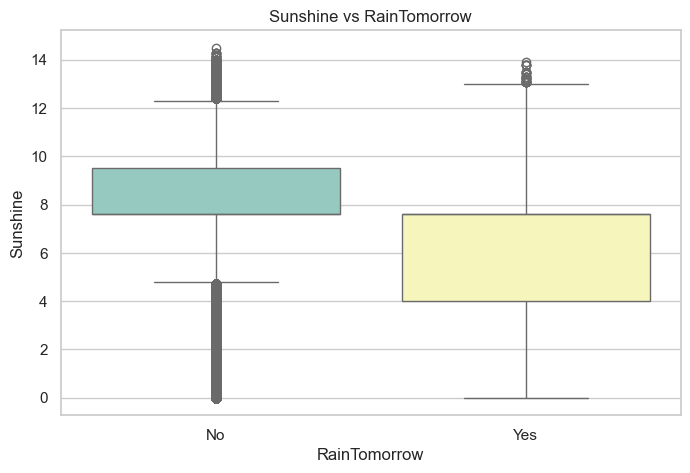

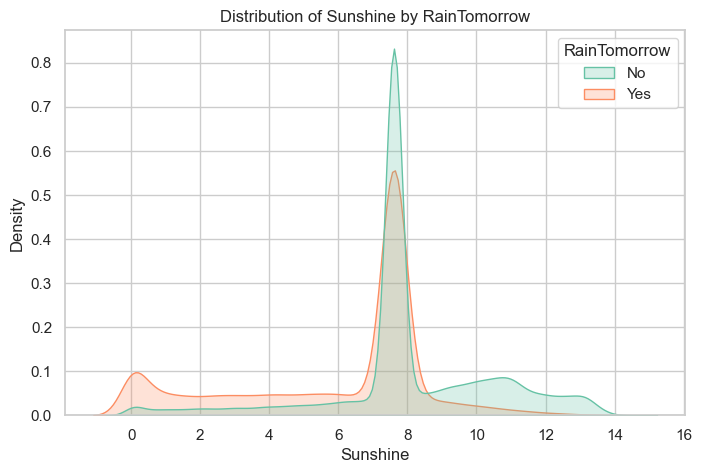

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


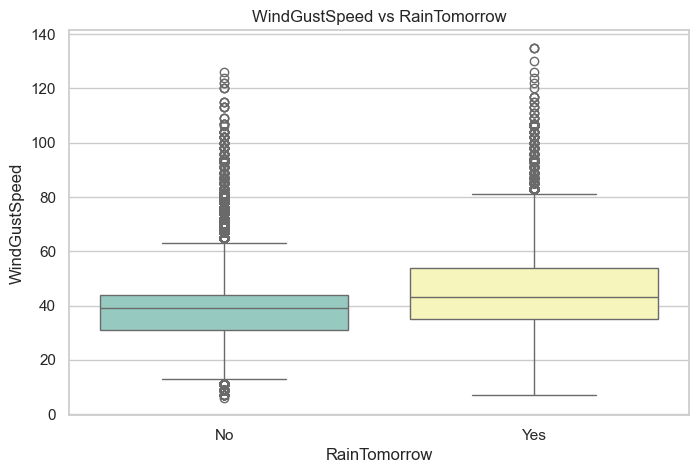

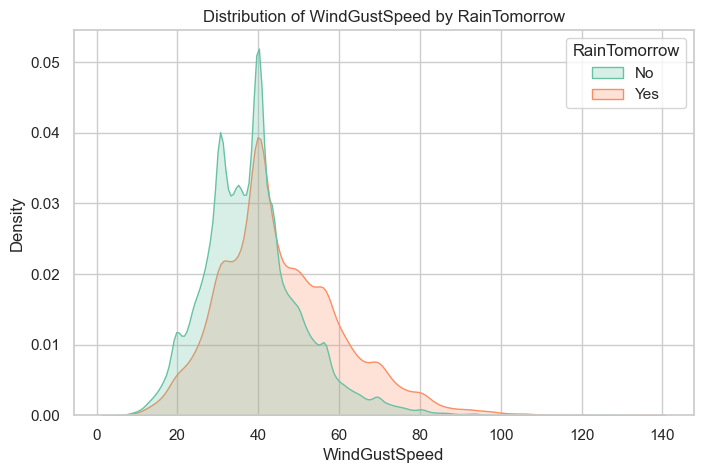

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


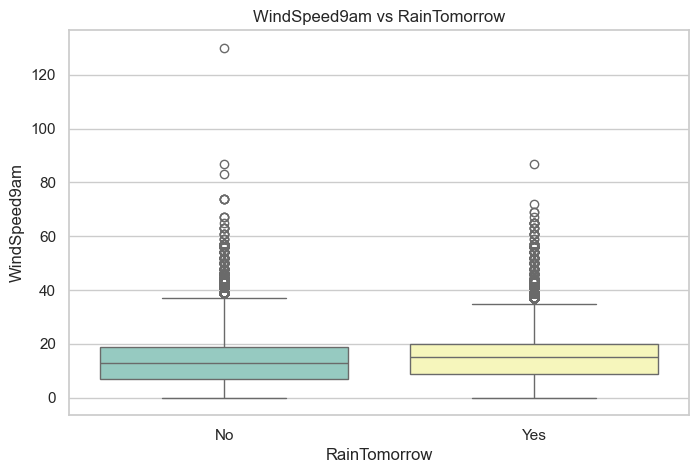

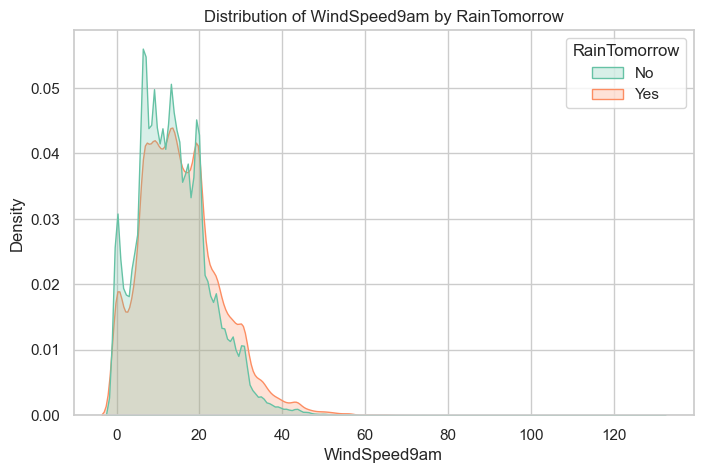

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


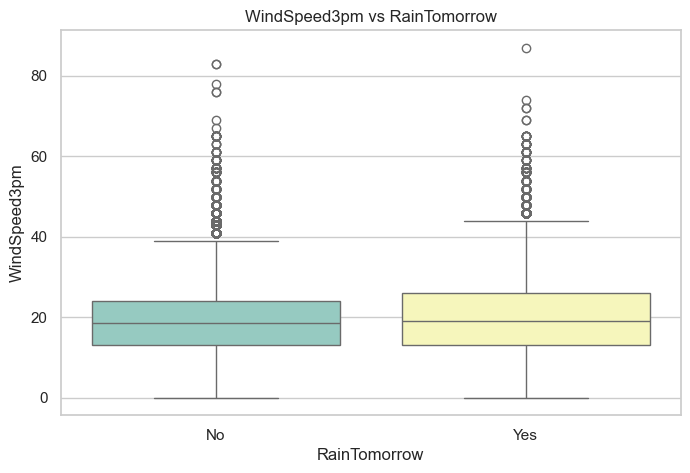

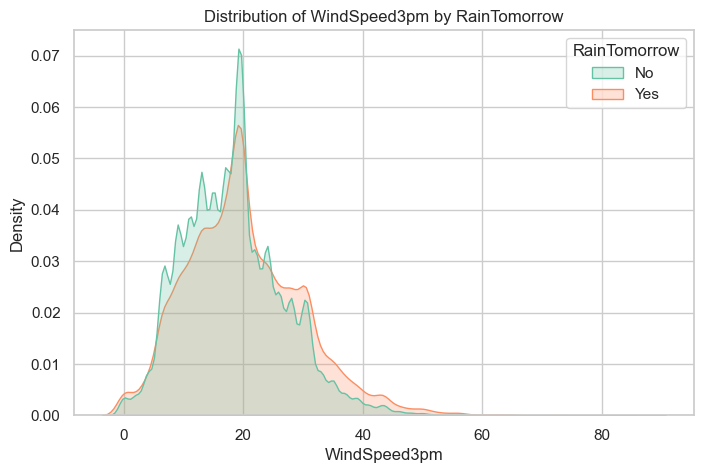

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


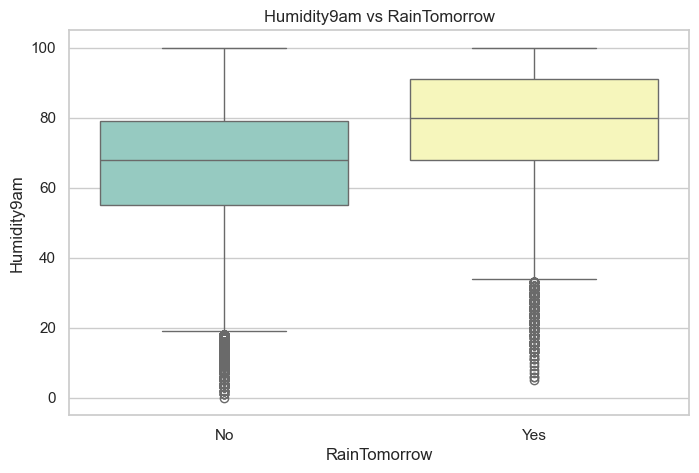

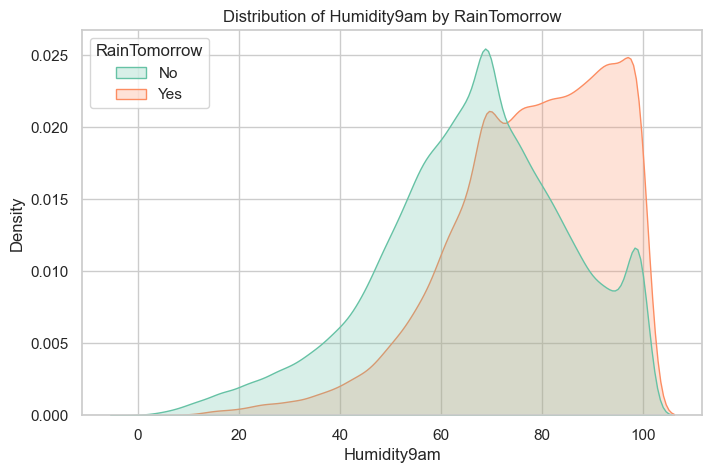

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


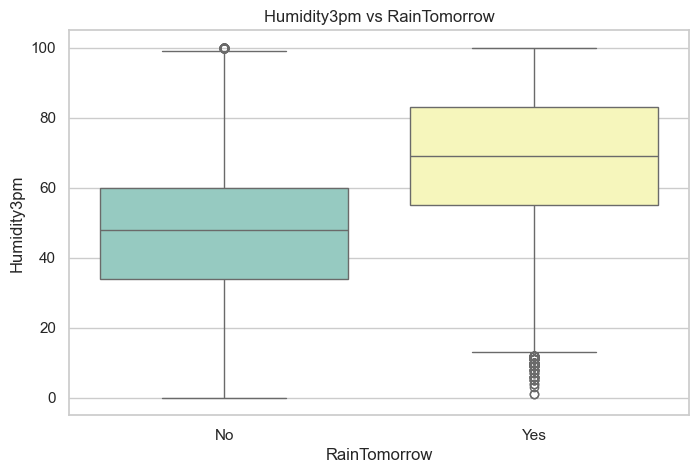

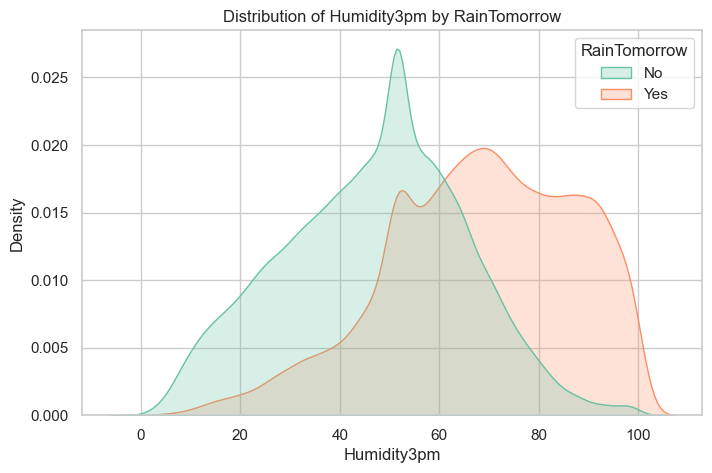

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


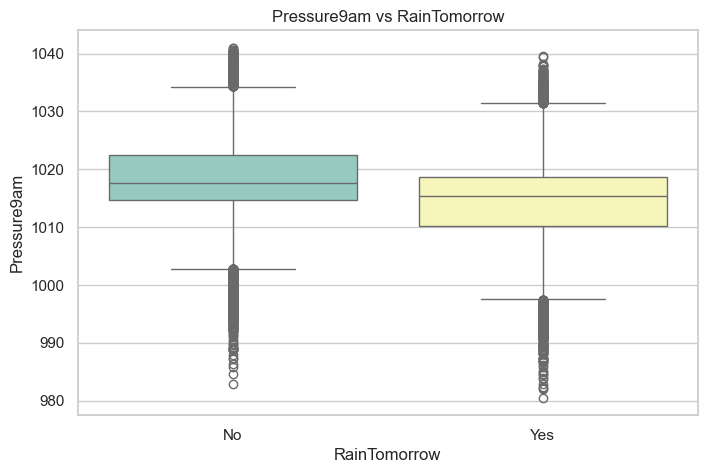

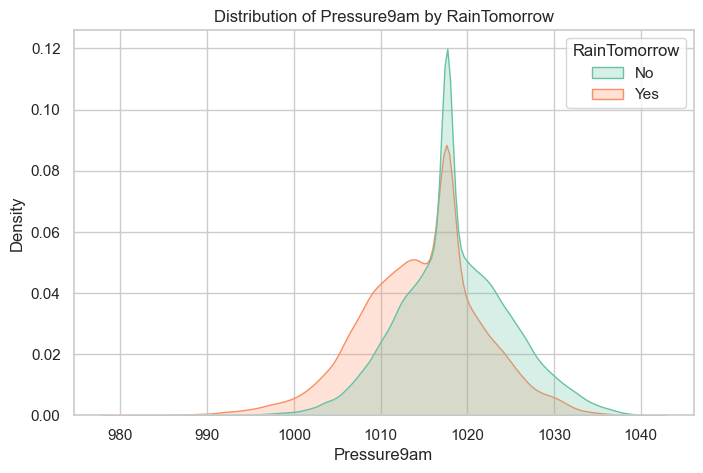

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


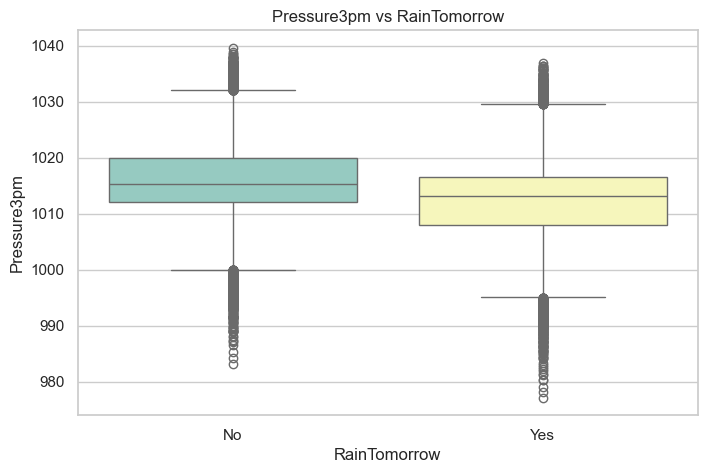

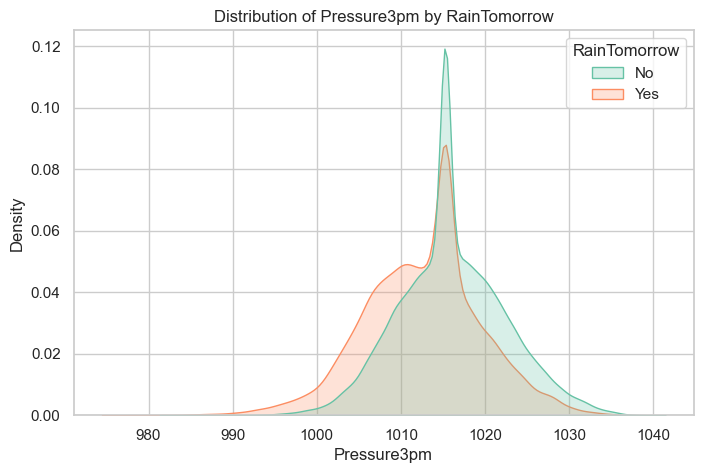

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


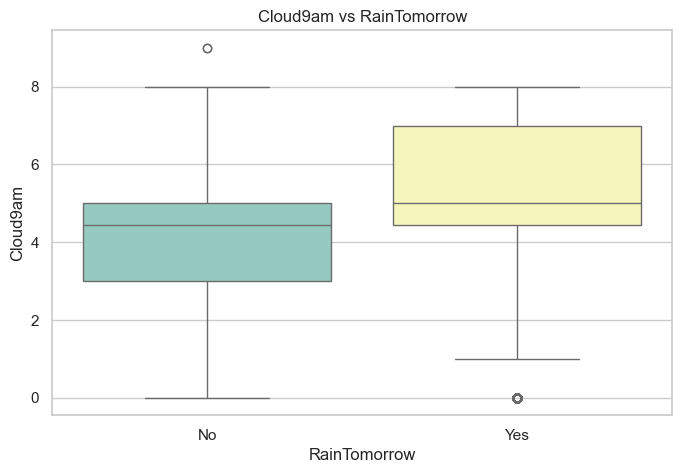

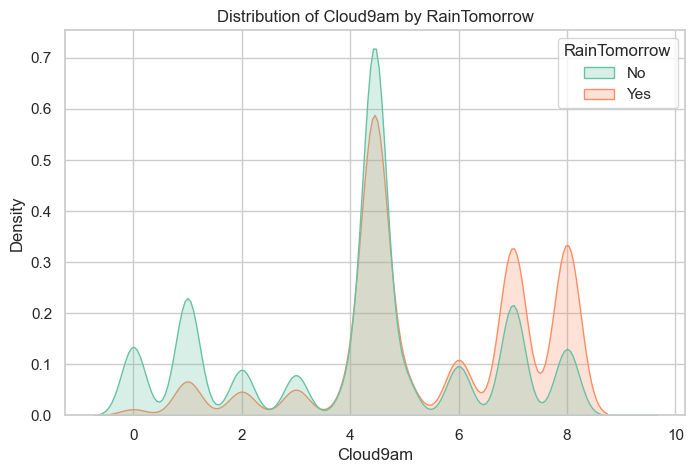

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


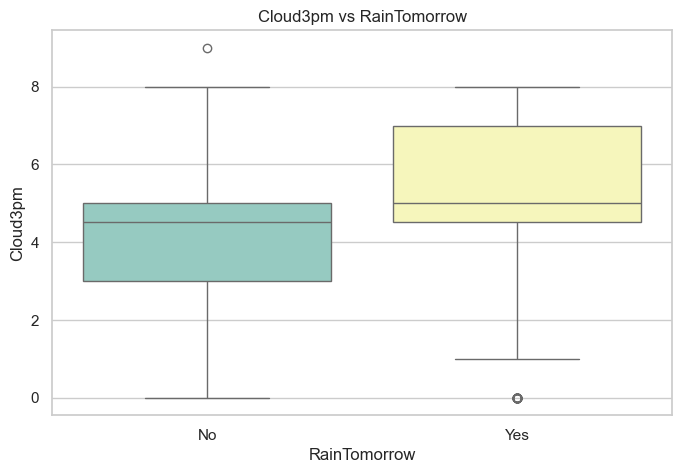

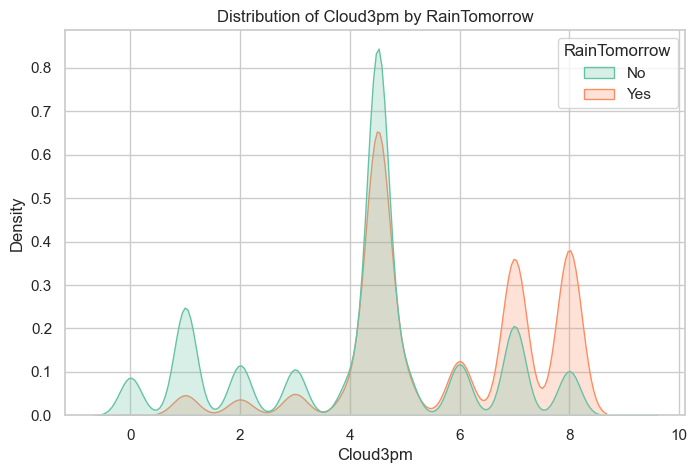

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


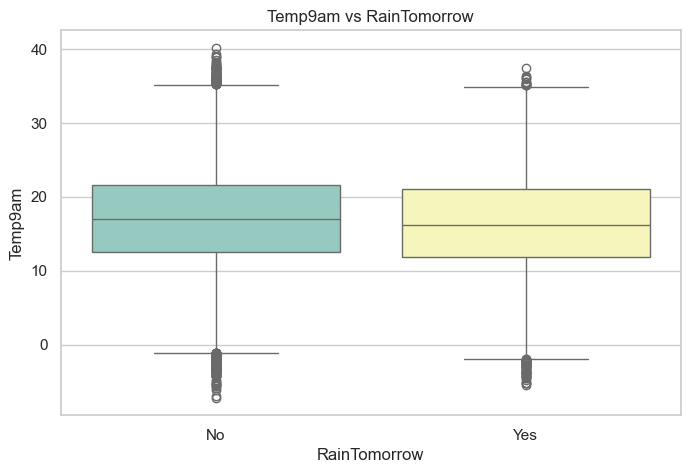

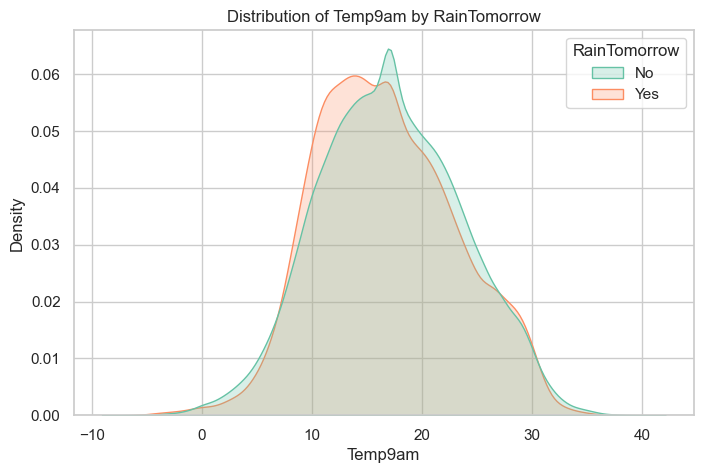

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


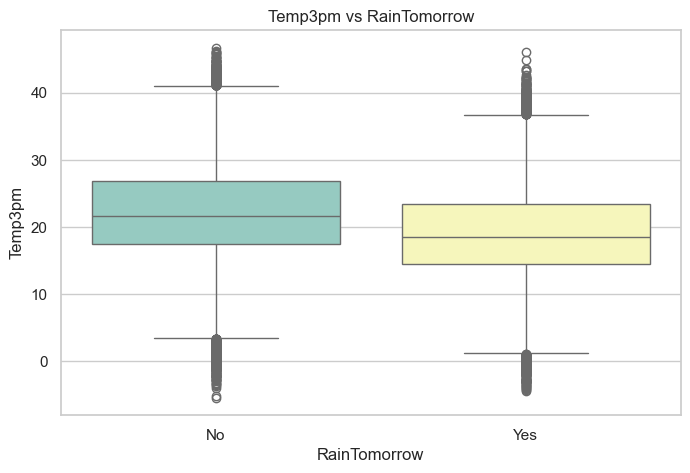

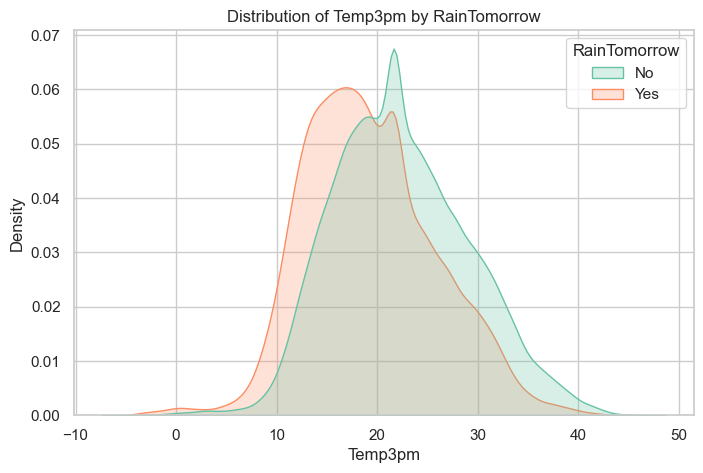

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


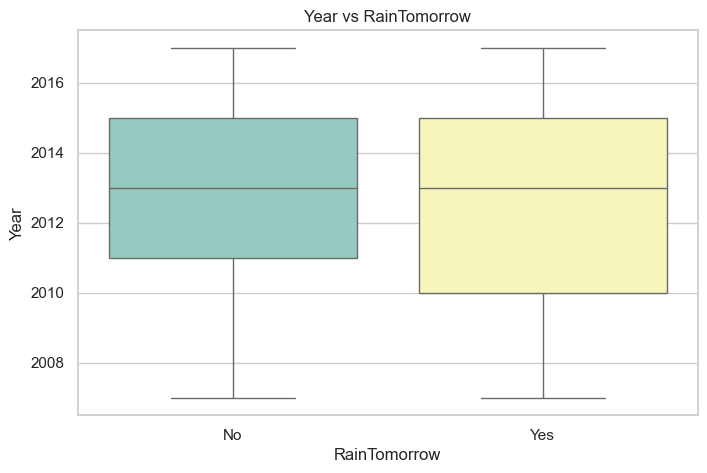

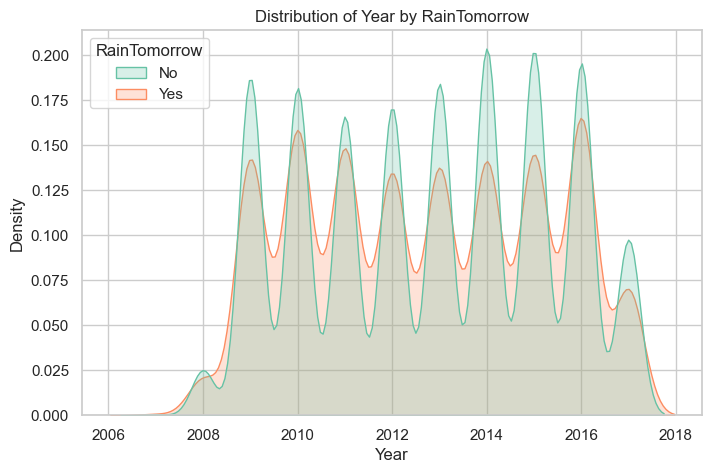

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


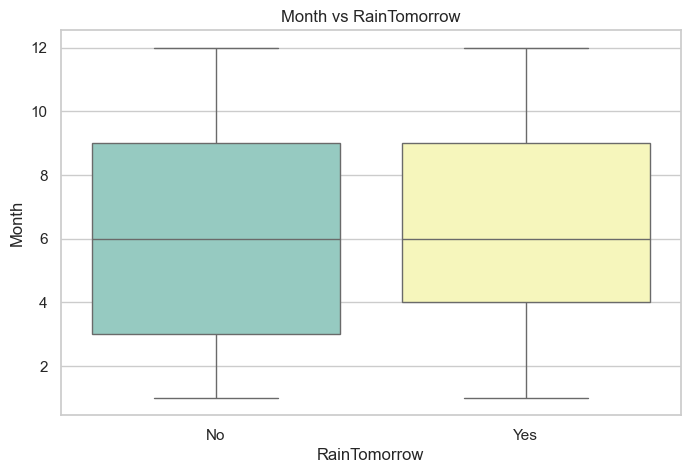

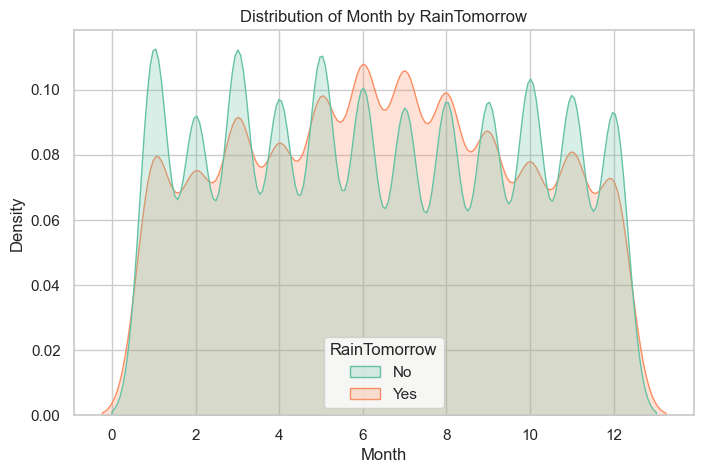

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


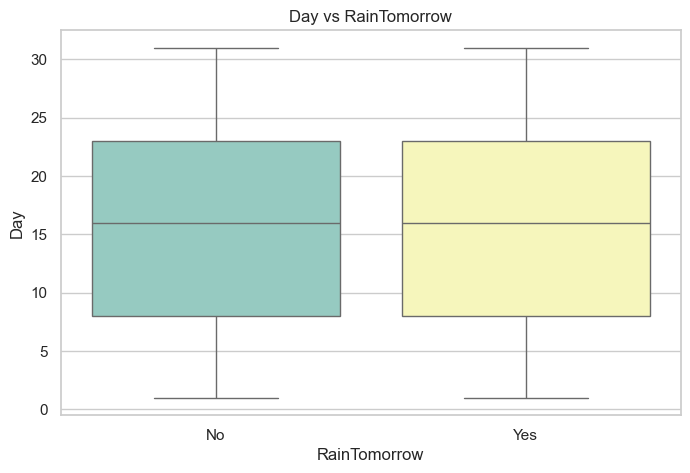

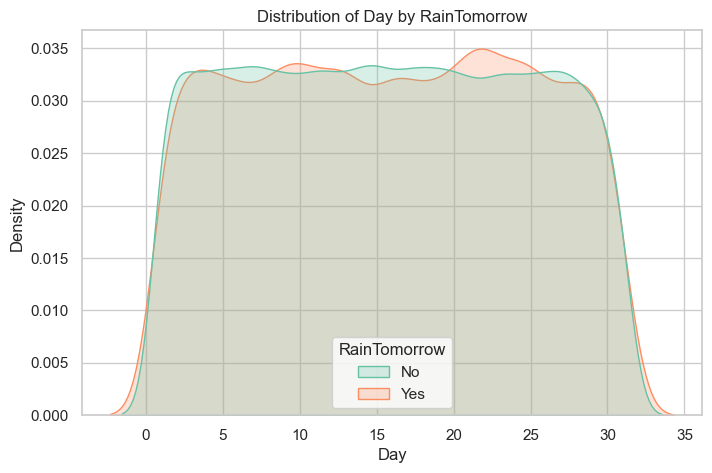

C:\Users\ryana\AppData\Local\Temp\ipykernel_23352\1580716285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")


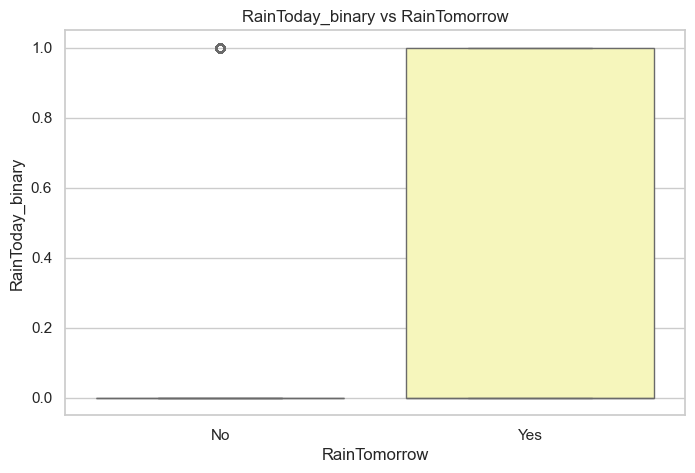

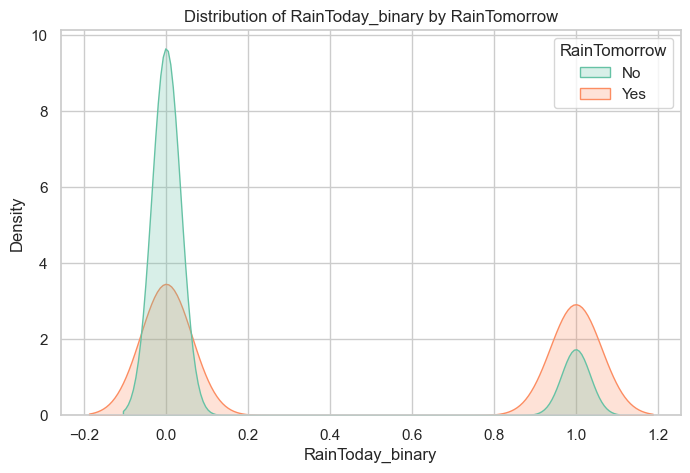

In [52]:
# Loop untuk plot
for i, col in enumerate(numerical_cols):
    plt.figure(figsize=(8,5))
    
    # Boxplot RainTomorrow vs fitur numerik
    sns.boxplot(x='RainTomorrow', y=col, data=data, palette="Set3")
    plt.title(f'{col} vs RainTomorrow')
    plt.ylabel(col)
    plt.xlabel("RainTomorrow")
    plt.show()
    
    # KDE plot (Distribusi per class)
    plt.figure(figsize=(8,5))
    sns.kdeplot(
        data=data, 
        x=col, 
        hue='RainTomorrow', 
        fill=True, 
        common_norm=False, 
        palette="Set2"
    )
    plt.title(f'Distribution of {col} by RainTomorrow')
    plt.xlabel(col)
    plt.show()